In [1]:
# cell 1
!pip install scikit-learn tensorflow pandas numpy matplotlib joblib

In [2]:
# cell 2
from pathlib import Path
import json
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [3]:
# cell 3
# mount drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Cell 4 — Reproducibility setup
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# cell 5 - ddefine paths
PREPARED_DATA_DIR = Path("/content/drive/MyDrive/datasets/demo5/prepared_audio_data")

OUTPUT_DIR = Path("/content/drive/MyDrive/datasets/demo5/trained_audio_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PREPARED_DATA_DIR / "audio_features.npy"
LABELS_PATH = PREPARED_DATA_DIR / "audio_labels.npy"
METADATA_PATH = PREPARED_DATA_DIR / "audio_window_metadata.csv"
FEATURE_INFO_PATH = PREPARED_DATA_DIR / "feature_info.json"

print("Features exists:", FEATURES_PATH.exists())
print("Labels exists:", LABELS_PATH.exists())
print("Metadata exists:", METADATA_PATH.exists())
print("Feature info exists:", FEATURE_INFO_PATH.exists())
print("Output dir:", OUTPUT_DIR)

Features exists: True
Labels exists: True
Metadata exists: True
Feature info exists: True
Output dir: /content/drive/MyDrive/datasets/demo5/trained_audio_model


In [6]:
# Cell 6 — Load prepared audio data
X = np.load(FEATURES_PATH)
y = np.load(LABELS_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

with open(FEATURE_INFO_PATH, "r") as file:
    feature_info = json.load(file)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Metadata shape:", metadata_df.shape)
print("Feature info:")
feature_info

X shape: (1179, 100, 46)
y shape: (1179,)
Metadata shape: (1179, 7)
Feature info:


{'sample_rate': 16000,
 'window_seconds': 5.0,
 'stride_seconds': 2.5,
 'frame_length_seconds': 0.064,
 'frame_hop_seconds': 0.05,
 'target_audio_frames': 100,
 'n_mfcc': 13,
 'feature_count': 46,
 'features': ['mfcc_1_to_13',
  'delta_mfcc_1_to_13',
  'delta2_mfcc_1_to_13',
  'rms',
  'zero_crossing_rate',
  'spectral_centroid',
  'spectral_bandwidth',
  'spectral_rolloff',
  'pitch_f0',
  'voicing_probability'],
 'label_mapping': {'truthful': 0, 'deceptive': 1}}

In [7]:
# Cell 7 — Check class distribution
label_counts = pd.Series(y).value_counts().sort_index()

print("Label counts:")
print(label_counts)

print("\nMetadata label distribution:")
print(metadata_df["label_name"].value_counts())

Label counts:
0    593
1    586
Name: count, dtype: int64

Metadata label distribution:
label_name
truthful     593
deceptive    586
Name: count, dtype: int64


In [8]:
# Cell 8 — Group-based train/val/test split
groups = metadata_df["video_id"].values

# First split: train+val vs test
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=SEED
)

train_val_idx, test_idx = next(
    gss_test.split(X, y, groups=groups)
)

X_train_val = X[train_val_idx]
y_train_val = y[train_val_idx]
metadata_train_val = metadata_df.iloc[train_val_idx].reset_index(drop=True)

X_test = X[test_idx]
y_test = y[test_idx]
metadata_test = metadata_df.iloc[test_idx].reset_index(drop=True)

# Second split: train vs validation
groups_train_val = metadata_train_val["video_id"].values

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1765,  # about 15% of total after 85% train_val
    random_state=SEED
)

train_idx, val_idx = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val[train_idx]
y_train = y_train_val[train_idx]
metadata_train = metadata_train_val.iloc[train_idx].reset_index(drop=True)

X_val = X_train_val[val_idx]
y_val = y_train_val[val_idx]
metadata_val = metadata_train_val.iloc[val_idx].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTrain labels:")
print(pd.Series(y_train).value_counts())

print("\nVal labels:")
print(pd.Series(y_val).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())

print("\nUnique train videos:", metadata_train["video_id"].nunique())
print("Unique val videos:", metadata_val["video_id"].nunique())
print("Unique test videos:", metadata_test["video_id"].nunique())

Train: (764, 100, 46) (764,)
Val: (202, 100, 46) (202,)
Test: (213, 100, 46) (213,)

Train labels:
0    429
1    335
Name: count, dtype: int64

Val labels:
1    138
0     64
Name: count, dtype: int64

Test labels:
1    113
0    100
Name: count, dtype: int64

Unique train videos: 83
Unique val videos: 19
Unique test videos: 19


In [9]:
# Cell 9 — Save split metadata
metadata_train.to_csv(OUTPUT_DIR / "audio_train_window_metadata.csv", index=False)
metadata_val.to_csv(OUTPUT_DIR / "audio_val_window_metadata.csv", index=False)
metadata_test.to_csv(OUTPUT_DIR / "audio_test_window_metadata.csv", index=False)

np.save(OUTPUT_DIR / "X_audio_train.npy", X_train)
np.save(OUTPUT_DIR / "X_audio_val.npy", X_val)
np.save(OUTPUT_DIR / "X_audio_test.npy", X_test)

np.save(OUTPUT_DIR / "y_audio_train.npy", y_train)
np.save(OUTPUT_DIR / "y_audio_val.npy", y_val)
np.save(OUTPUT_DIR / "y_audio_test.npy", y_test)

print("Saved split files to:", OUTPUT_DIR)

Saved split files to: /content/drive/MyDrive/datasets/demo5/trained_audio_model


In [10]:
# Cell 10 — Create summary features for baseline model
def summarize_audio_sequence(X_sequence):
    """
    Converts sequence data:
    (samples, time_steps, feature_count)

    into static summary data:
    (samples, feature_count * 4)
    """

    mean_features = np.mean(X_sequence, axis=1)
    std_features = np.std(X_sequence, axis=1)
    min_features = np.min(X_sequence, axis=1)
    max_features = np.max(X_sequence, axis=1)

    return np.concatenate(
        [mean_features, std_features, min_features, max_features],
        axis=1
    )


X_train_summary = summarize_audio_sequence(X_train)
X_val_summary = summarize_audio_sequence(X_val)
X_test_summary = summarize_audio_sequence(X_test)

print("X_train_summary:", X_train_summary.shape)
print("X_val_summary:", X_val_summary.shape)
print("X_test_summary:", X_test_summary.shape)

X_train_summary: (764, 184)
X_val_summary: (202, 184)
X_test_summary: (213, 184)


In [11]:
# Cell 11 — Train Random Forest baseline
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_summary, y_train)

val_probs_rf = rf_model.predict_proba(X_val_summary)[:, 1]
val_preds_rf = (val_probs_rf >= 0.5).astype(int)

test_probs_rf = rf_model.predict_proba(X_test_summary)[:, 1]
test_preds_rf = (test_probs_rf >= 0.5).astype(int)

print("Validation classification report:")
print(classification_report(y_val, val_preds_rf, target_names=["truthful", "deceptive"]))

print("Test classification report:")
print(classification_report(y_test, test_preds_rf, target_names=["truthful", "deceptive"]))

Validation classification report:
              precision    recall  f1-score   support

    truthful       0.50      0.89      0.64        64
   deceptive       0.92      0.59      0.72       138

    accuracy                           0.68       202
   macro avg       0.71      0.74      0.68       202
weighted avg       0.79      0.68      0.69       202

Test classification report:
              precision    recall  f1-score   support

    truthful       0.65      0.93      0.77       100
   deceptive       0.90      0.57      0.70       113

    accuracy                           0.74       213
   macro avg       0.78      0.75      0.73       213
weighted avg       0.79      0.74      0.73       213



In [12]:
# Cell 12 — Baseline metrics function
def calculate_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics["roc_auc"] = None

    return metrics


rf_val_metrics = calculate_metrics(y_val, val_preds_rf, val_probs_rf)
rf_test_metrics = calculate_metrics(y_test, test_preds_rf, test_probs_rf)

print("RF validation metrics:")
print(rf_val_metrics)

print("\nRF test metrics:")
print(rf_test_metrics)

RF validation metrics:
{'accuracy': 0.6831683168316832, 'precision': 0.9204545454545454, 'recall': 0.5869565217391305, 'f1': 0.7168141592920354, 'roc_auc': 0.8731884057971016}

RF test metrics:
{'accuracy': 0.7370892018779343, 'precision': 0.9014084507042254, 'recall': 0.5663716814159292, 'f1': 0.6956521739130435, 'roc_auc': 0.8421238938053098}


In [14]:
# Cell 13 — Save baseline model
joblib.dump(rf_model, OUTPUT_DIR / "audio_random_forest_baseline.pkl")

baseline_metrics = {
    "model": "RandomForestClassifier",
    "validation": rf_val_metrics,
    "test": rf_test_metrics,
    "input_type": "window_summary_features",
    "summary_features": ["mean", "std", "min", "max"]
}

with open(OUTPUT_DIR / "audio_baseline_metrics.json", "w") as file:
    json.dump(baseline_metrics, file, indent=4)

print("Saved Random Forest baseline.")

Saved Random Forest baseline.


In [15]:
# Cell 14 — Build BiLSTM model
time_steps = X_train.shape[1]
feature_count = X_train.shape[2]

print("Time steps:", time_steps)
print("Feature count:", feature_count)

def build_audio_bilstm_model(time_steps, feature_count):
    inputs = layers.Input(shape=(time_steps, feature_count))

    x = layers.Masking(mask_value=0.0)(inputs)

    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.25,
            recurrent_dropout=0.0
        )
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            32,
            return_sequences=False,
            dropout=0.25,
            recurrent_dropout=0.0
        )
    )(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

    return model


audio_bilstm_model = build_audio_bilstm_model(time_steps, feature_count)
audio_bilstm_model.summary()

Time steps: 100
Feature count: 46


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 46)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100, 46)   │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 100, 46)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 100)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 128)  │     56,832 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,321 (407.50 KB)

 Trainable params: 104,321 (407.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Cell 15 — Compute class weights
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique, counts))

total = len(y_train)
class_weight = {
    0: total / (2 * class_counts.get(0, 1)),
    1: total / (2 * class_counts.get(1, 1)),
}

print("Class counts:", class_counts)
print("Class weights:", class_weight)

Class counts: {np.int64(0): np.int64(429), np.int64(1): np.int64(335)}
Class weights: {0: np.float64(0.8904428904428905), 1: np.float64(1.1402985074626866)}


In [17]:
# Cell 16 — Train BiLSTM
checkpoint_path = OUTPUT_DIR / "best_audio_bilstm_model.keras"

training_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = audio_bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    class_weight=class_weight,
    callbacks=training_callbacks,
    verbose=1
)

Epoch 1/80
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4896 - auc: 0.5339 - loss: 0.6897 - precision: 0.4297 - recall: 0.6124
Epoch 1: val_auc improved from None to 0.63728, saving model to /content/drive/MyDrive/datasets/demo5/trained_audio_model/best_audio_bilstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/demo5/trained_audio_model/best_audio_bilstm_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.5157 - auc: 0.5449 - loss: 0.6903 - precision: 0.4614 - recall: 0.6239 - val_accuracy: 0.5891 - val_auc: 0.6373 - val_loss: 0.6854 - val_precision: 0.7778 - val_recall: 0.5580 - learning_rate: 1.0000e-04
Epoch 2/80
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5200 - auc: 0.5481 - loss: 0.6880 - precision: 0.4524 - recall: 0.6047
Epoch 2: val_auc improved from 0.63728 to 0.71796, saving model to /content/drive/MyDrive/datasets/demo5/trained_audio_model/best_audio_bilstm_model.keras

Epoch 2: finished saving model to /con

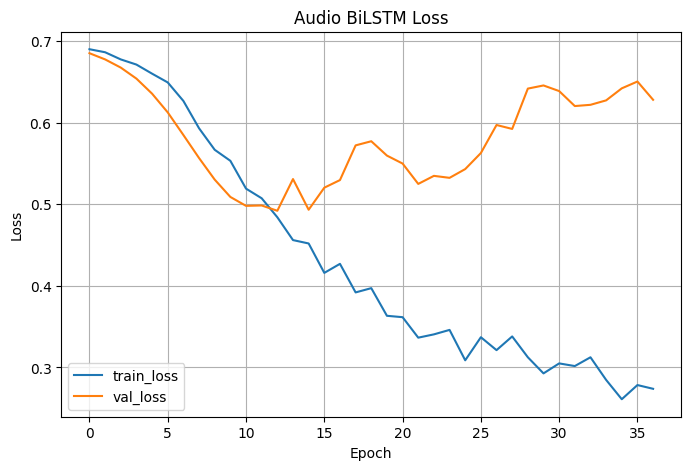

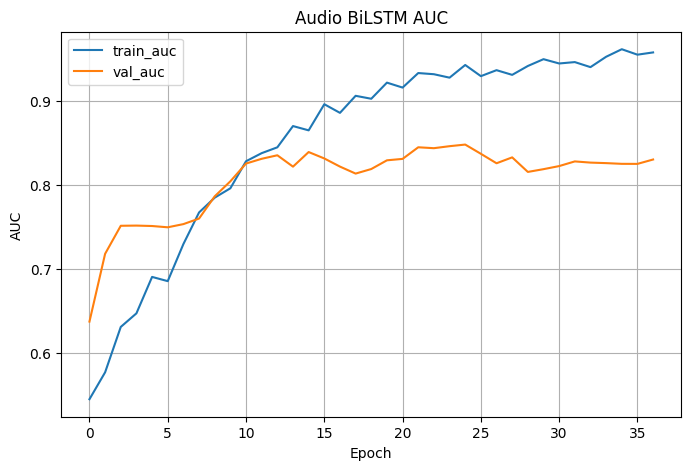

In [18]:
# Cell 17 — Plot training curves
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / "audio_bilstm_training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio BiLSTM Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["auc"], label="train_auc")
plt.plot(history_df["val_auc"], label="val_auc")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Audio BiLSTM AUC")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Cell 18 — Evaluate BiLSTM
best_audio_model = tf.keras.models.load_model(OUTPUT_DIR / "best_audio_bilstm_model.keras")

val_probs_bilstm = best_audio_model.predict(X_val).ravel()
val_preds_bilstm = (val_probs_bilstm >= 0.5).astype(int)

test_probs_bilstm = best_audio_model.predict(X_test).ravel()
test_preds_bilstm = (test_probs_bilstm >= 0.5).astype(int)

print("Validation classification report:")
print(classification_report(y_val, val_preds_bilstm, target_names=["truthful", "deceptive"]))

print("Test classification report:")
print(classification_report(y_test, test_preds_bilstm, target_names=["truthful", "deceptive"]))

bilstm_val_metrics = calculate_metrics(y_val, val_preds_bilstm, val_probs_bilstm)
bilstm_test_metrics = calculate_metrics(y_test, test_preds_bilstm, test_probs_bilstm)

print("BiLSTM validation metrics:")
print(bilstm_val_metrics)

print("\nBiLSTM test metrics:")
print(bilstm_test_metrics)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Validation classification report:
              precision    recall  f1-score   support

    truthful       0.54      0.81      0.65        64
   deceptive       0.89      0.68      0.77       138

    accuracy                           0.72       202
   macro avg       0.71      0.75      0.71       202
weighted avg       0.78      0.72      0.73       202

Test classification report:
              precision    recall  f1-score   support

    truthful       0.68      0.88      0.77       100
   deceptive       0.86      0.63      0.72       113

    accuracy                           0.75       213
   macro avg       0.77      0.75      0.74       213
weighted avg       0.77      0.75      0.74       213

BiLSTM validation metrics:
{'accuracy': 0.7227722772277227, 'precision': 0.8867924528301887, 'recall': 0.6811594202898551, 'f1': 0.7704918032786885, 'roc_auc': 0.8481657608695652}

BiLSTM test metrics:
{'acc

In [20]:
# Cell 19 — Confusion matrices
print("Random Forest test confusion matrix:")
print(confusion_matrix(y_test, test_preds_rf))

print("\nBiLSTM test confusion matrix:")
print(confusion_matrix(y_test, test_preds_bilstm))

Random Forest test confusion matrix:
[[93  7]
 [49 64]]

BiLSTM test confusion matrix:
[[88 12]
 [42 71]]


In [21]:
# Cell 20 — Save final BiLSTM model and metrics
final_model_path = OUTPUT_DIR / "final_audio_bilstm_model.keras"
best_audio_model.save(final_model_path)

audio_bilstm_metrics = {
    "model": "Audio_BiLSTM",
    "input_shape": {
        "time_steps": int(time_steps),
        "feature_count": int(feature_count)
    },
    "validation": bilstm_val_metrics,
    "test": bilstm_test_metrics,
    "training_config": {
        "epochs": 80,
        "batch_size": 16,
        "learning_rate": 1e-4,
        "class_weight": {
            str(k): float(v) for k, v in class_weight.items()
        }
    }
}

with open(OUTPUT_DIR / "audio_bilstm_metrics.json", "w") as file:
    json.dump(audio_bilstm_metrics, file, indent=4)

print("Saved final model:", final_model_path)
print("Saved metrics:", OUTPUT_DIR / "audio_bilstm_metrics.json")

Saved final model: /content/drive/MyDrive/datasets/demo5/trained_audio_model/final_audio_bilstm_model.keras
Saved metrics: /content/drive/MyDrive/datasets/demo5/trained_audio_model/audio_bilstm_metrics.json


In [22]:
# Cell 21 — Compare baseline vs BiLSTM
comparison_df = pd.DataFrame([
    {
        "model": "Random Forest Baseline",
        **rf_test_metrics
    },
    {
        "model": "Audio BiLSTM",
        **bilstm_test_metrics
    }
])

comparison_df.to_csv(OUTPUT_DIR / "audio_model_comparison.csv", index=False)

comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest Baseline,0.737089,0.901408,0.566372,0.695652,0.842124
1,Audio BiLSTM,0.746479,0.855422,0.628319,0.724490,0.774248


In [23]:
# Cell 22 — Save model package info
model_package_info = {
    "prepared_data_source": str(PREPARED_DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "models_saved": {
        "random_forest_baseline": "audio_random_forest_baseline.pkl",
        "best_audio_bilstm": "best_audio_bilstm_model.keras",
        "final_audio_bilstm": "final_audio_bilstm_model.keras"
    },
    "metrics_saved": {
        "baseline_metrics": "audio_baseline_metrics.json",
        "bilstm_metrics": "audio_bilstm_metrics.json",
        "comparison": "audio_model_comparison.csv",
        "training_history": "audio_bilstm_training_history.csv"
    },
    "feature_info": feature_info
}

with open(OUTPUT_DIR / "audio_model_package_info.json", "w") as file:
    json.dump(model_package_info, file, indent=4)

print("Audio model package complete.")
for path in OUTPUT_DIR.iterdir():
    print(path.name)

Audio model package complete.
audio_train_window_metadata.csv
audio_val_window_metadata.csv
audio_test_window_metadata.csv
X_audio_train.npy
X_audio_val.npy
X_audio_test.npy
y_audio_train.npy
y_audio_val.npy
y_audio_test.npy
audio_random_forest_baseline.pkl
audio_baseline_metrics.json
best_audio_bilstm_model.keras
audio_bilstm_training_history.csv
final_audio_bilstm_model.keras
audio_bilstm_metrics.json
audio_model_comparison.csv
audio_model_package_info.json
